# 🧠 Logistic Regression: Step-by-Step 

Logistic Regression is one of the most popular algorithms for **Binary Classification** (predicting "Yes/No", "True/False", or "0/1"). 

### The Goal
In this guide, we will build a model that takes some data (features) and predicts which category it belongs to by:
1. Doing some math to get a "score".
2. Squashing that score into a probability between 0 and 1.
3. Automatically "learning" from its mistakes.


In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## 0. Load and Explore the Dataset 📂
- read the data from a CSV file,
- preview the first few rows,
- check the unique values in each column,
- select the input and target-related columns for later use.

In [28]:
data = {
    "x1": [1,2,3,4,5,6,7,8],
    "x2": [2,3,3,5,5,7,8,9],
    "label": [0,0,0,0,1,1,1,1]
}

df = pd.DataFrame(data)

X = df[["x1","x2"]].values
y = df["label"].values



## 3. Extract Features and Target
`x` represents the input feature (hours studied) and `y` represents the target variable (exam score).

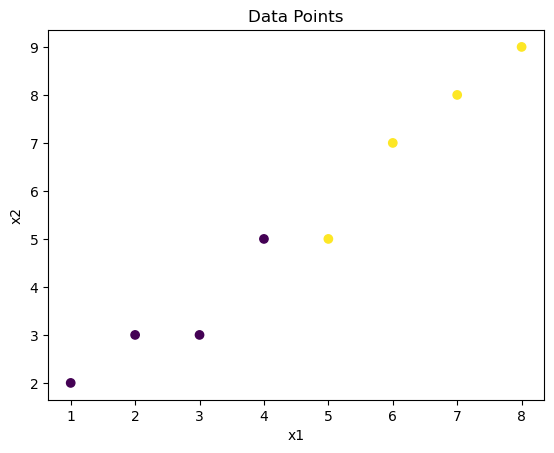

In [29]:
plt.scatter(X[:,0], X[:,1], c=y)
plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Data Points")
plt.show()

## 1. The Sigmoid "Squashing" Function 🍋

Imagine you have a number like 100 or -50. We want to turn that into a probability (like 0.9 or 0.1). The **Sigmoid function** is like a magic mirror that squashes any number into the range of 0 to 1.

*   If the input is **high**, the output is close to **1** (Highly likely).
*   If the input is **low**, the output is close to **0** (Unlikely).
*   If the input is **0**, the output is exactly **0.5** (50/50 chance).

$$\sigma(z) = \frac{1}{1 + e^{-z}}$$


In [30]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))


In [31]:
n_samples, n_features = X.shape

weights = np.zeros(n_features)
bias = 0

learning_rate = 0.01
epochs = 1000

## Cost Function and Gradient Calculation

The binary cross-entropy loss function measures the performance of our model. It penalizes incorrect classifications exponentially.

$$J(\theta) = -\frac{1}{m} \sum_{i=1}^{m} [y^{(i)} \log(h_\theta(x^{(i)})) + (1-y^{(i)}) \log(1-h_\theta(x^{(i)}))]$$


The gradients of the cost function with respect to the weights $\theta$ and bias $b$ are used for optimization:

$$\frac{\partial J}{\partial \theta_j} = \frac{1}{m} \sum_{i=1}^{m} (h_\theta(x^{(i)}) - y^{(i)}) x_j^{(i)}$$
$$\frac{\partial J}{\partial b} = \frac{1}{m} \sum_{i=1}^{m} (h_\theta(x^{(i)}) - y^{(i)})$$

In [32]:
for _ in range(epochs):

    # linear model
    z = np.dot(X, weights) + bias
    
    # prediction
    y_pred = sigmoid(z)

    # gradients
    dw = (1/n_samples) * np.dot(X.T, (y_pred - y))
    db = (1/n_samples) * np.sum(y_pred - y)

    # update parameters
    weights -= learning_rate * dw
    bias -= learning_rate * db

In [33]:
def predict(X):
    z = np.dot(X, weights) + bias
    probs = sigmoid(z)
    return [1 if i >= 0.5 else 0 for i in probs]

In [34]:
predict(X)

[0, 0, 1, 1, 1, 1, 1, 1]

## 7. Visualize Data & Decision Boundary 📉

To help you understand how our model is learning to separate the two classes, let's visualize the "fence" or **Decision Boundary** it has created.


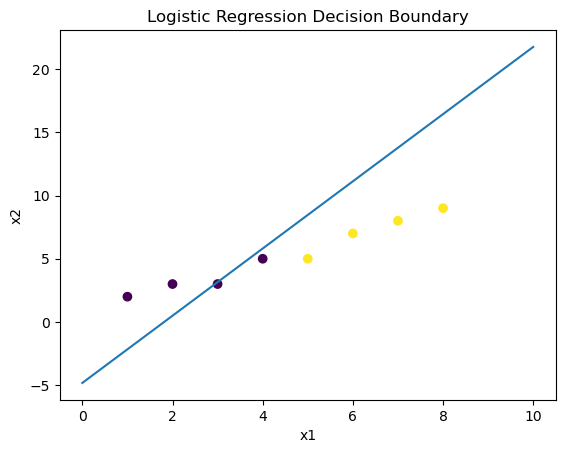

In [35]:
x_values = np.linspace(0,10,100)

decision_boundary = -(weights[0]*x_values + bias) / weights[1]

plt.scatter(X[:,0], X[:,1], c=y)
plt.plot(x_values, decision_boundary)

plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Logistic Regression Decision Boundary")

plt.show()